In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import LearningRateScheduler, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Load dataset

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

y_train_full = y_train_full.ravel()
y_test = y_test.ravel()

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("Antal klasser:", len(np.unique(y_train_full)))
print("Klasser:", np.unique(y_train_full))

X_train_full: (60000, 28, 28)
y_train_full: (60000,)
X_test: (10000, 28, 28)
y_test: (10000,)
Antal klasser: 10
Klasser: [0 1 2 3 4 5 6 7 8 9]


In [3]:
# Klassnamn

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

for i, name in enumerate(class_names):
    print(i, name)

0 T-shirt/top
1 Trouser
2 Pullover
3 Dress
4 Coat
5 Sandal
6 Shirt
7 Sneaker
8 Bag
9 Ankle boot


In [4]:
# Klassfördelning

class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,T-shirt/top,6000
1,1,Trouser,6000
2,2,Pullover,6000
3,3,Dress,6000
4,4,Coat,6000
5,5,Sandal,6000
6,6,Shirt,6000
7,7,Sneaker,6000
8,8,Bag,6000
9,9,Ankle boot,6000


In [5]:
# Skapa subset

def create_balanced_subset(X, y, samples_per_class=300, random_state=42):

    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=300,
    random_state=42
)

print("X_subset_raw:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset_raw: (3000, 28, 28)
y_subset: (3000,)


In [6]:
# Skapa valideringsset

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.20,
    random_state=42,
    stratify=y_subset
)

print("X_train_raw:", X_train_raw.shape)
print("X_val_raw:", X_val_raw.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train_raw: (2400, 28, 28)
X_val_raw: (600, 28, 28)
y_train: (2400,)
y_val: (600,)


In [7]:
# Normalisera

X_train = X_train_raw.astype("float32") / 255.0
X_val = X_val_raw.astype("float32") / 255.0

X_test_norm = X_test.astype("float32") / 255.0

print("X_train min/max:", X_train.min(), X_train.max())
print("X_val min/max:", X_val.min(), X_val.max())
print("X_train shape:", X_train.shape)

X_train min/max: 0.0 1.0
X_val min/max: 0.0 1.0
X_train shape: (2400, 28, 28)


In [8]:
# Funktion för modell

def build_model(
        num_filters_1=32,
        num_filters_2=64,
        kernel_size=(3, 3),
        dense_units=128,
        learning_rate=0.001,
        dropout_rate=0.0,
        l2_strength=0.0
):
    """
    Bygger och kompilerar en Keras CNN-modell för med angivna hyperparametrar.
    """

    kernels_regularizer = (
        regularizers.l2(l2_strength)
        if l2_strength > 0
        else None
    )

    model = keras.Sequential([
        layers.Input(shape=(28, 28, 1)),

        layers.Conv2D(num_filters_1, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),

        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(num_filters_2, kernel_size=kernel_size, activation="relu",
                      padding="same", kernel_regularizer=kernels_regularizer),
                      
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
    ])

    model.add(layers.Dense(dense_units, activation="relu",
                           kernel_regularizer=kernels_regularizer))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [9]:
def plot_history(history, title="Träningskurvor"):
    """
    Plottar tränings- och valideringsförlust och noggrannhet över epoker.
    """

    history_df = pd.DataFrame(history.history)

    plt.figure(figsize=(12, 5))

    # Förlust
    plt.subplot(1, 2, 1)
    plt.plot(history_df["loss"], label="Training loss")
    plt.plot(history_df["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss")
    plt.legend()

    # Noggrannhet
    plt.subplot(1, 2, 2)
    plt.plot(history_df["accuracy"], label="Training accuracy")
    plt.plot(history_df["val_accuracy"], label="Validation accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")
    plt.legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [10]:
# Funktion för experiment

def run_experiment(
        name,
        epochs=15,
        learning_rate=0.001,
        batch_size=64,
        num_filters_1=32,
        num_filters_2=64,
        kernel_size=(3, 3),
        dense_units=128,
        dropout_rate=0.0,
        l2_strength=0.0,
        callbacks=None,
        verbose=0
):
    model = build_model(
        num_filters_1=num_filters_1,
        num_filters_2=num_filters_2,
        kernel_size=kernel_size,
        dense_units=dense_units,
        learning_rate=learning_rate,
        dropout_rate=dropout_rate,
        l2_strength=l2_strength
    )

    print(f"\nExperiment: {name}")
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose
    )

    training_time = time.time() - start_time

    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_acc  = history.history["val_accuracy"][-1]
    val_loss = history.history["val_loss"][-1]


    print(f"Antal epoker:   {len(history.history['loss'])}")
    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:    {training_time:.2f} sekunder")

    plot_history(history, title=name)

    return history, {
        "name": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "val_accuracy": val_acc,
        "val_loss": val_loss,
        "epochs_trained": len(history.history["loss"]),
        "training_time": training_time
    }


Experiment: Få epoker
Antal epoker:   5
Train accuracy:      0.8537
Train loss:          0.3950
Validation accuracy: 0.8383
Validation loss:     0.4321
Träningstid:    3.69 sekunder


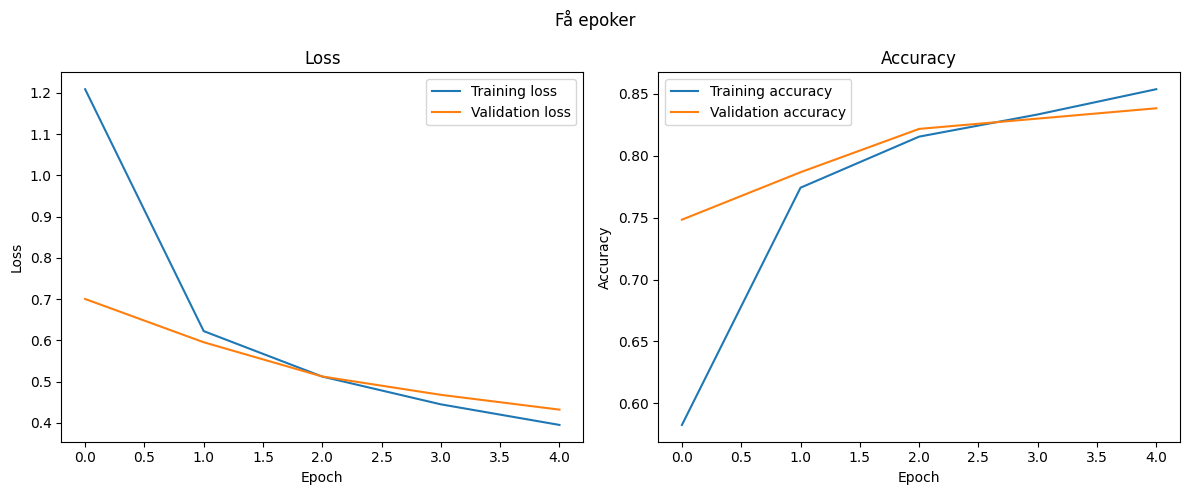


Experiment: Grundmodell
Antal epoker:   15
Train accuracy:      0.9433
Train loss:          0.1825
Validation accuracy: 0.8617
Validation loss:     0.4574
Träningstid:    8.40 sekunder


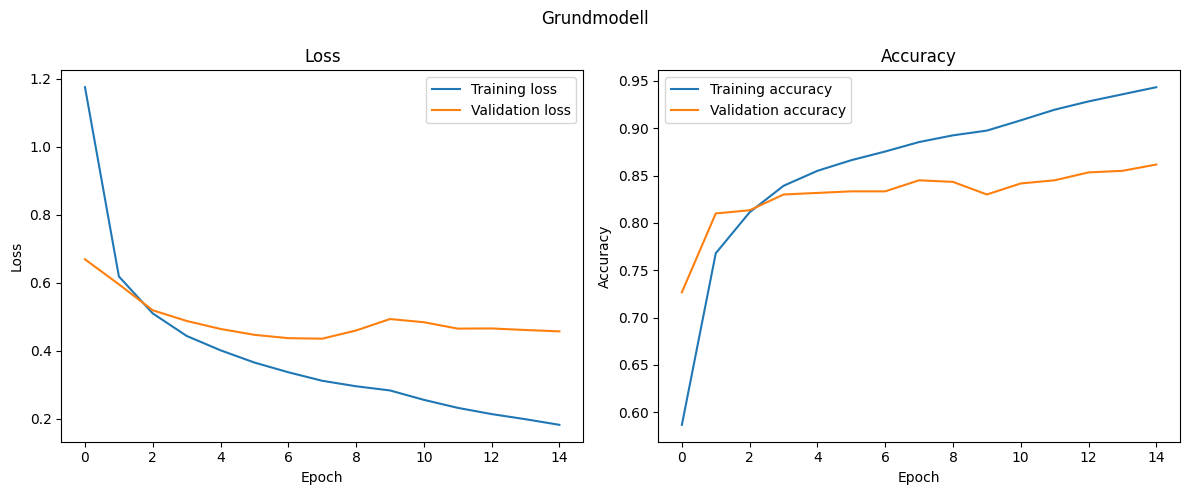


Experiment: Många epoker
Antal epoker:   30
Train accuracy:      0.9696
Train loss:          0.0778
Validation accuracy: 0.8350
Validation loss:     0.6816
Träningstid:    15.84 sekunder


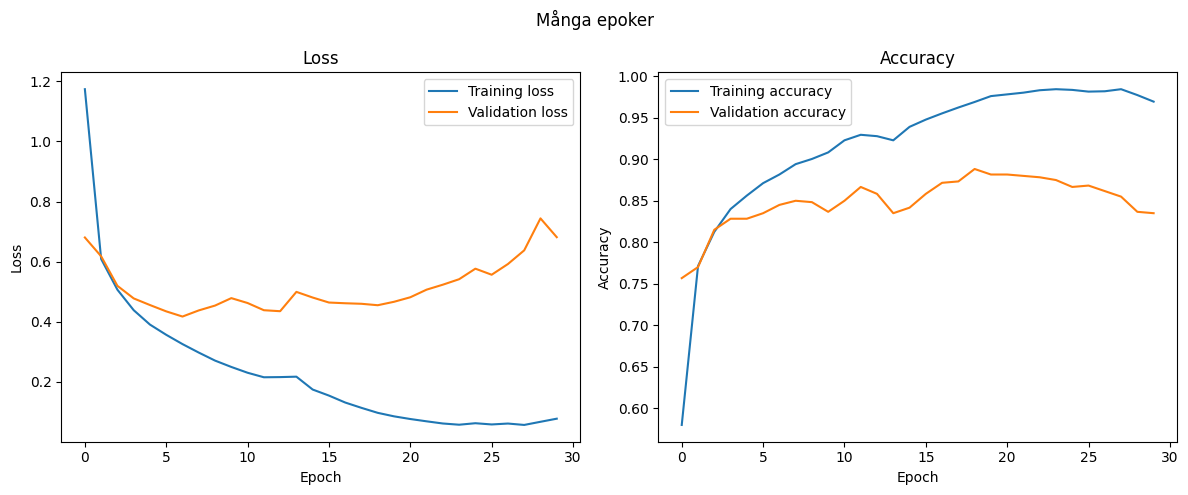

        name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
   Få epoker        0.853750    0.395047      0.838333  0.432139               5       3.690404
 Grundmodell        0.943333    0.182484      0.861667  0.457438              15       8.400747
Många epoker        0.969583    0.077788      0.835000  0.681650              30      15.837261


In [11]:
results_general = []

# Experiment 1 – Epoker

h1, r1 = run_experiment("Få epoker",    epochs=5)
h2, r2 = run_experiment("Grundmodell",  epochs=15)
h3, r3 = run_experiment("Många epoker", epochs=30)
results_general.extend([r1, r2, r3])

print(pd.DataFrame(results_general).to_string(index=False))


Experiment: Liten batch
Antal epoker:   15
Train accuracy:      0.9583
Train loss:          0.1264
Validation accuracy: 0.8650
Validation loss:     0.4873
Träningstid:    10.31 sekunder


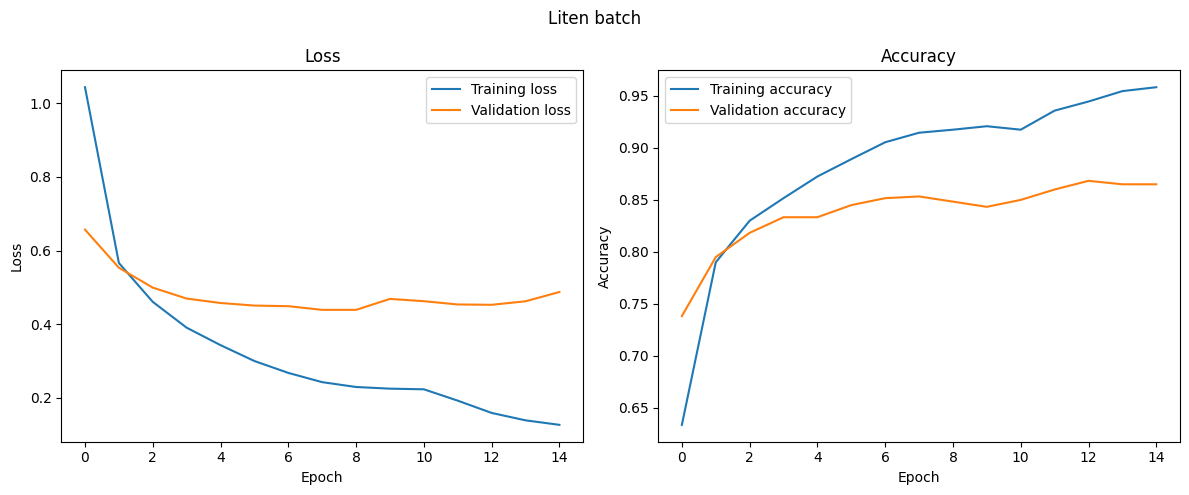


Experiment: Normal batch
Antal epoker:   15
Train accuracy:      0.9479
Train loss:          0.1533
Validation accuracy: 0.8567
Validation loss:     0.4935
Träningstid:    8.42 sekunder


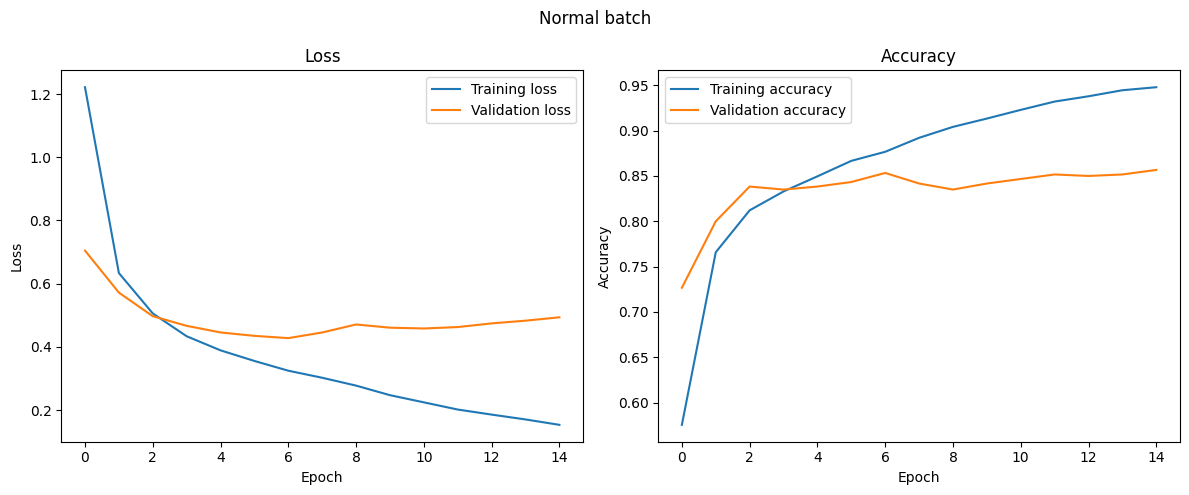


Experiment: Stor batch
Antal epoker:   15
Train accuracy:      0.8754
Train loss:          0.3580
Validation accuracy: 0.8533
Validation loss:     0.4549
Träningstid:    6.91 sekunder


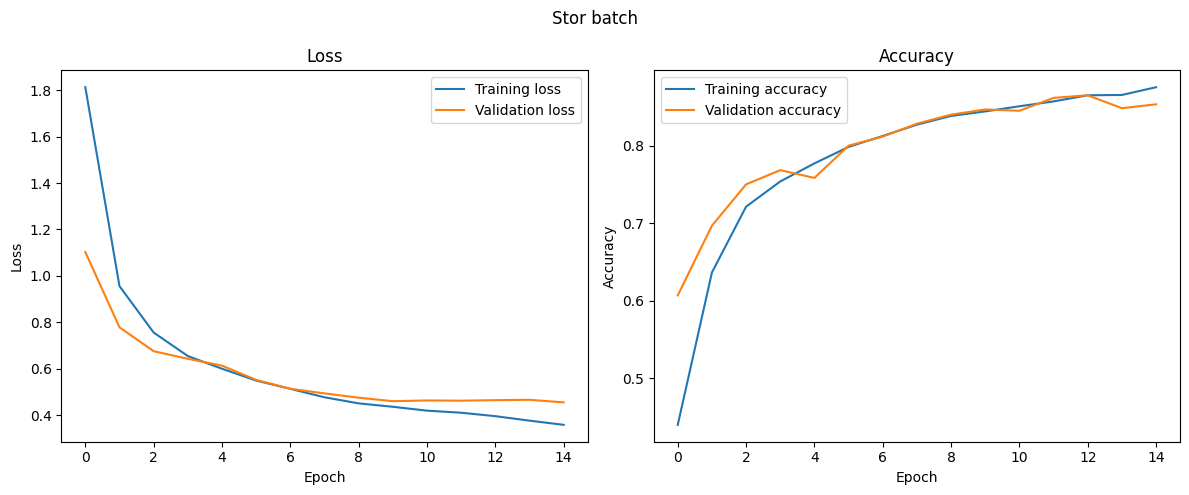

        name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
   Få epoker        0.853750    0.395047      0.838333  0.432139               5       3.690404
 Grundmodell        0.943333    0.182484      0.861667  0.457438              15       8.400747
Många epoker        0.969583    0.077788      0.835000  0.681650              30      15.837261
 Liten batch        0.958333    0.126442      0.865000  0.487274              15      10.311773
Normal batch        0.947917    0.153334      0.856667  0.493546              15       8.420186
  Stor batch        0.875417    0.358007      0.853333  0.454866              15       6.912342


In [12]:
# Experiment 2 – Batch size

h4, r4 = run_experiment("Liten batch",  batch_size=32)
h5, r5 = run_experiment("Normal batch", batch_size=64)
h6, r6 = run_experiment("Stor batch",   batch_size=256)
results_general.extend([r4, r5, r6])

print(pd.DataFrame(results_general).to_string(index=False))


Experiment: Få filter
Antal epoker:   15
Train accuracy:      0.9262
Train loss:          0.2131
Validation accuracy: 0.8550
Validation loss:     0.4619
Träningstid:    5.88 sekunder


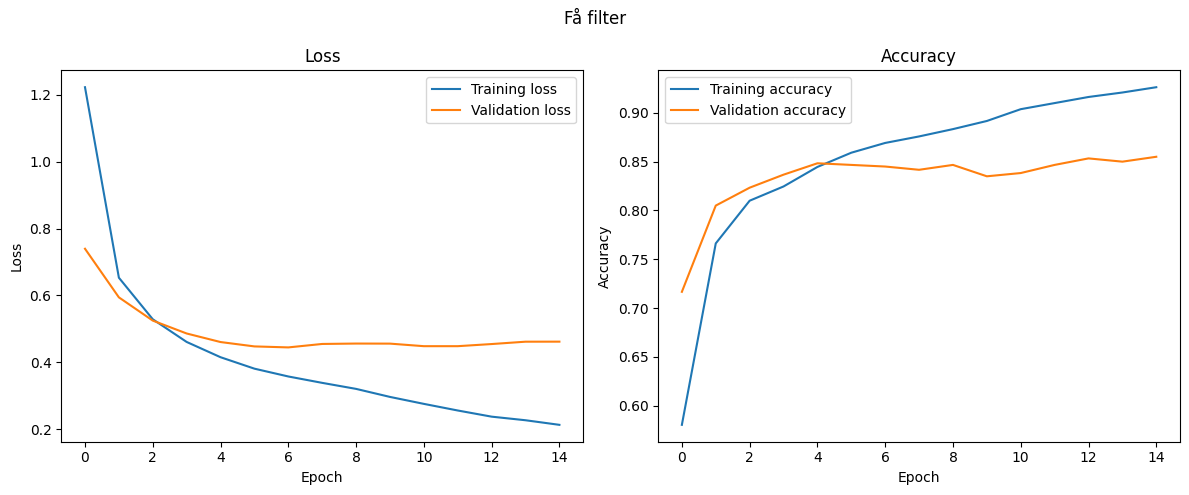


Experiment: Grundmodell filters
Antal epoker:   15
Train accuracy:      0.9217
Train loss:          0.2200
Validation accuracy: 0.8383
Validation loss:     0.5394
Träningstid:    8.75 sekunder


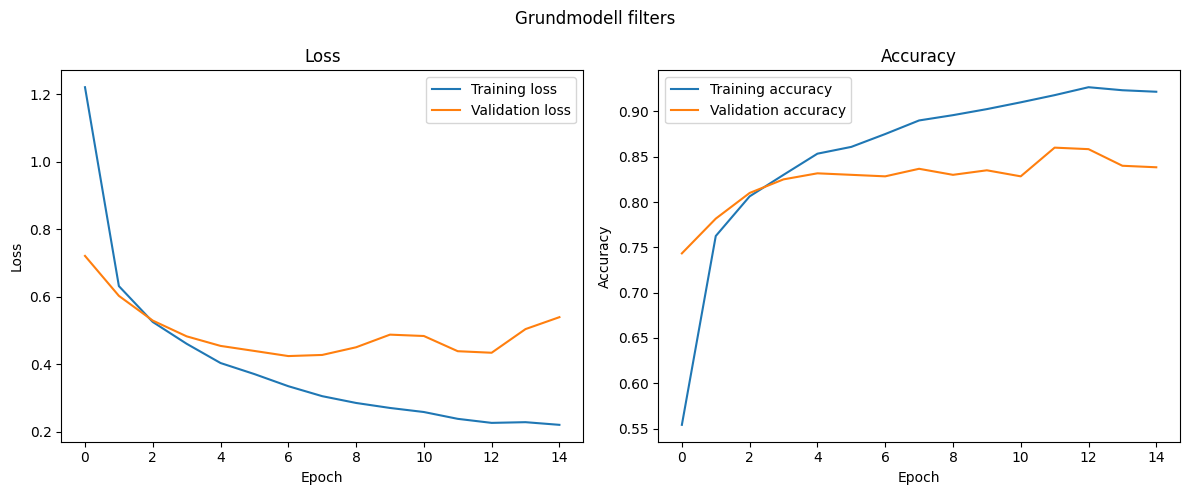


Experiment: Många filter
Antal epoker:   15
Train accuracy:      0.9200
Train loss:          0.2140
Validation accuracy: 0.8650
Validation loss:     0.4802
Träningstid:    17.01 sekunder


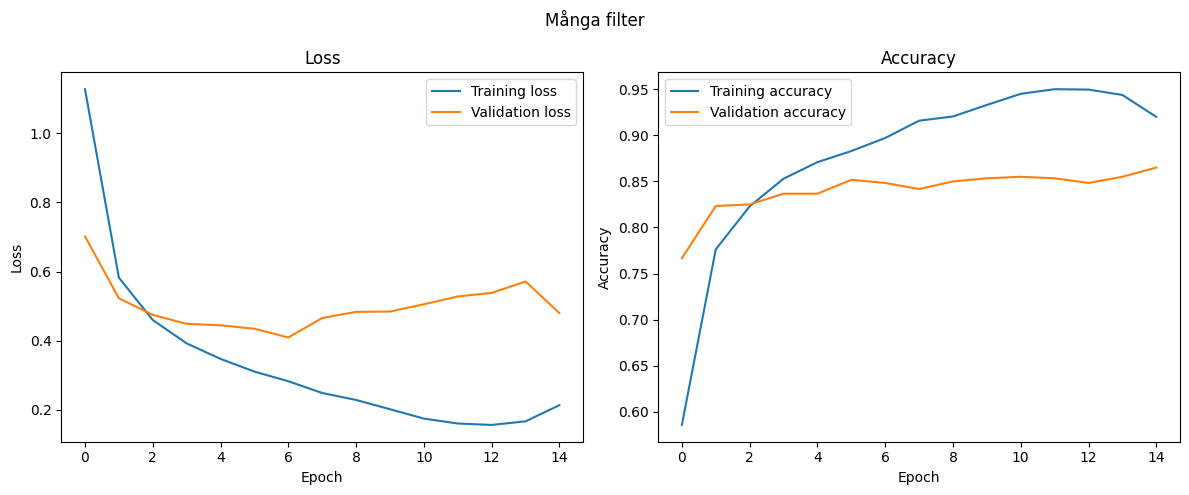

               name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
          Få epoker        0.853750    0.395047      0.838333  0.432139               5       3.690404
        Grundmodell        0.943333    0.182484      0.861667  0.457438              15       8.400747
       Många epoker        0.969583    0.077788      0.835000  0.681650              30      15.837261
        Liten batch        0.958333    0.126442      0.865000  0.487274              15      10.311773
       Normal batch        0.947917    0.153334      0.856667  0.493546              15       8.420186
         Stor batch        0.875417    0.358007      0.853333  0.454866              15       6.912342
          Få filter        0.926250    0.213105      0.855000  0.461891              15       5.884743
Grundmodell filters        0.921667    0.219979      0.838333  0.539367              15       8.749968
       Många filter        0.920000    0.213964      0.865000  0.480183  

In [13]:
# Experiment 3 – Antal filter

h7, r7 = run_experiment("Få filter",    num_filters_1=16, num_filters_2=32)
h8, r8 = run_experiment("Grundmodell filters", num_filters_1=32, num_filters_2=64)
h9, r9 = run_experiment("Många filter", num_filters_1=64, num_filters_2=128)
results_general.extend([r7, r8, r9])

print(pd.DataFrame(results_general).to_string(index=False))


Experiment: Ingen reg
Antal epoker:   15
Train accuracy:      0.9342
Train loss:          0.1772
Validation accuracy: 0.8517
Validation loss:     0.4863
Träningstid:    7.82 sekunder


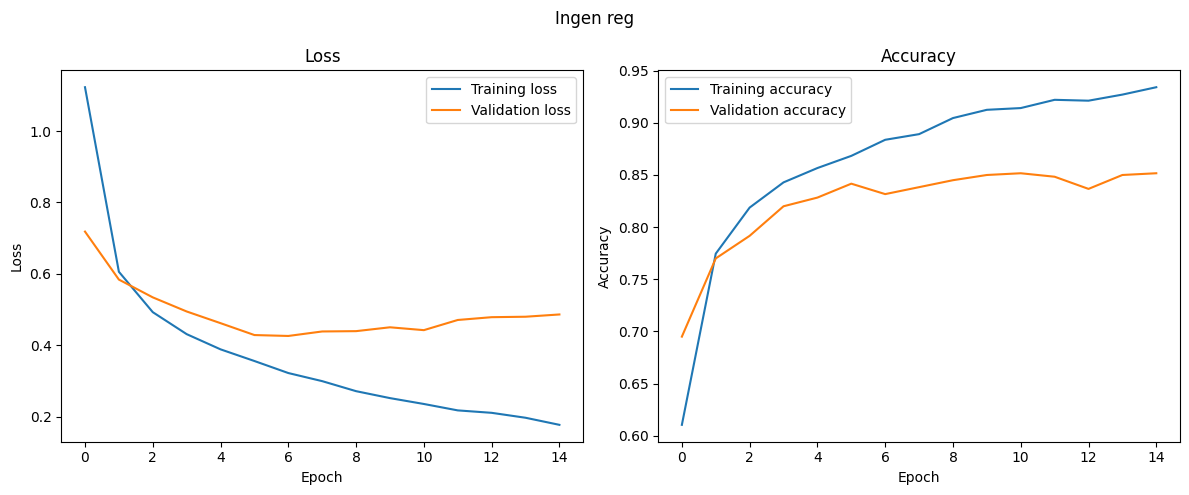


Experiment: Dropout 0.3
Antal epoker:   15
Train accuracy:      0.9300
Train loss:          0.2120
Validation accuracy: 0.8517
Validation loss:     0.4364
Träningstid:    8.10 sekunder


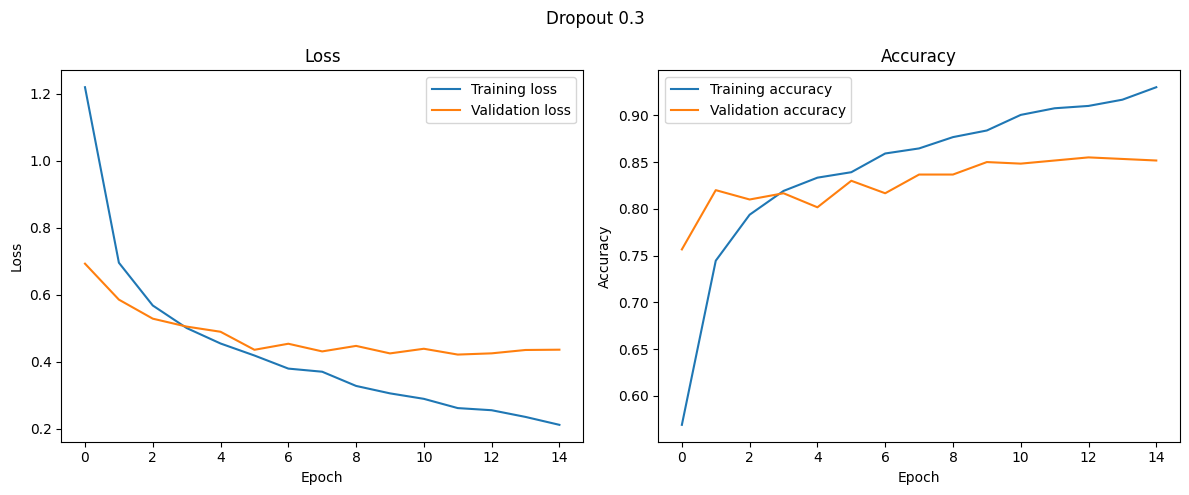


Experiment: Dropout 0.5
Antal epoker:   15
Train accuracy:      0.8904
Train loss:          0.3027
Validation accuracy: 0.8450
Validation loss:     0.4521
Träningstid:    7.92 sekunder


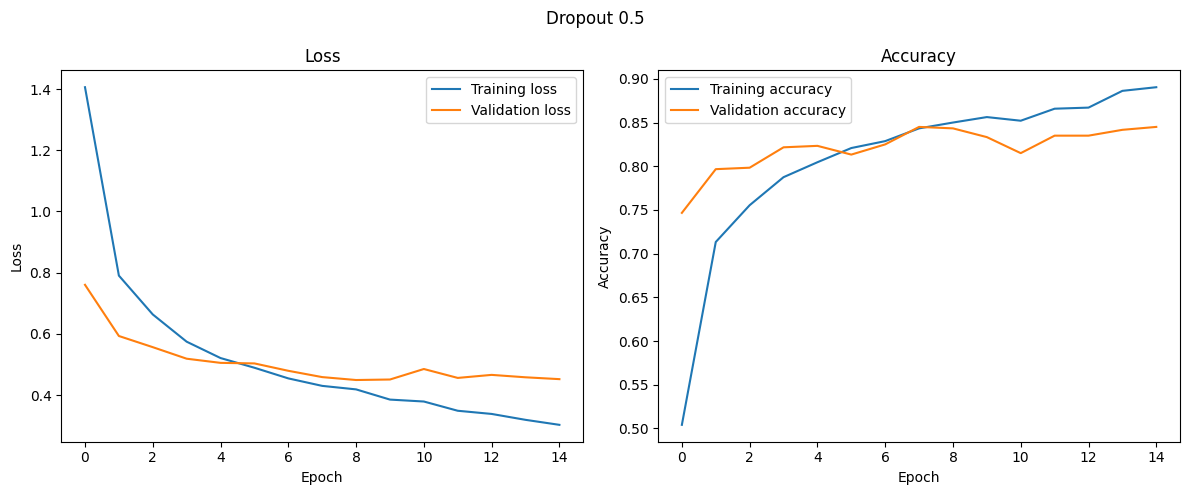


Experiment: L2
Antal epoker:   15
Train accuracy:      0.9250
Train loss:          0.3501
Validation accuracy: 0.8450
Validation loss:     0.6096
Träningstid:    7.79 sekunder


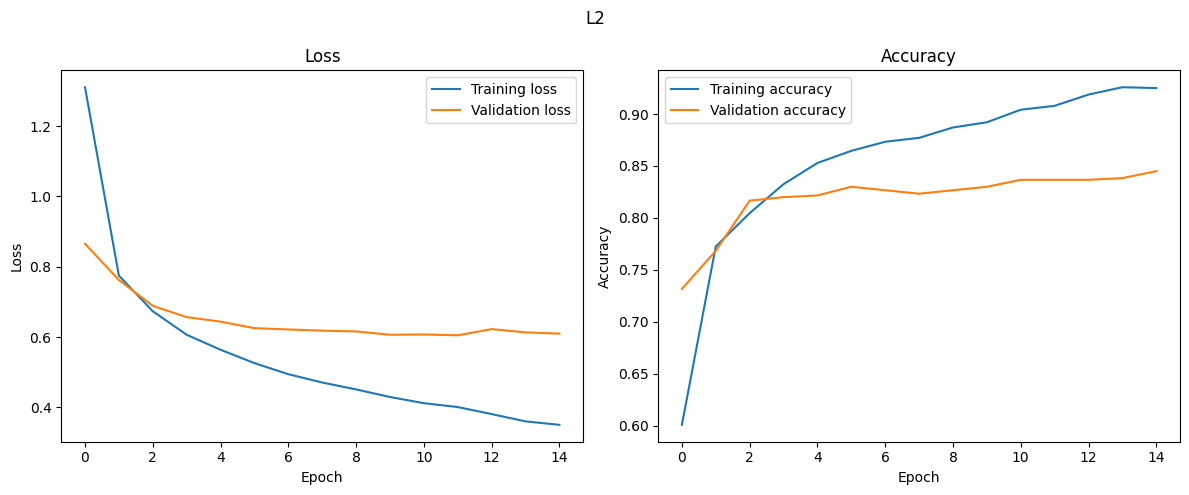


Experiment: Early Stopping
Antal epoker:   14
Train accuracy:      0.9346
Train loss:          0.1966
Validation accuracy: 0.8567
Validation loss:     0.4431
Träningstid:    7.30 sekunder


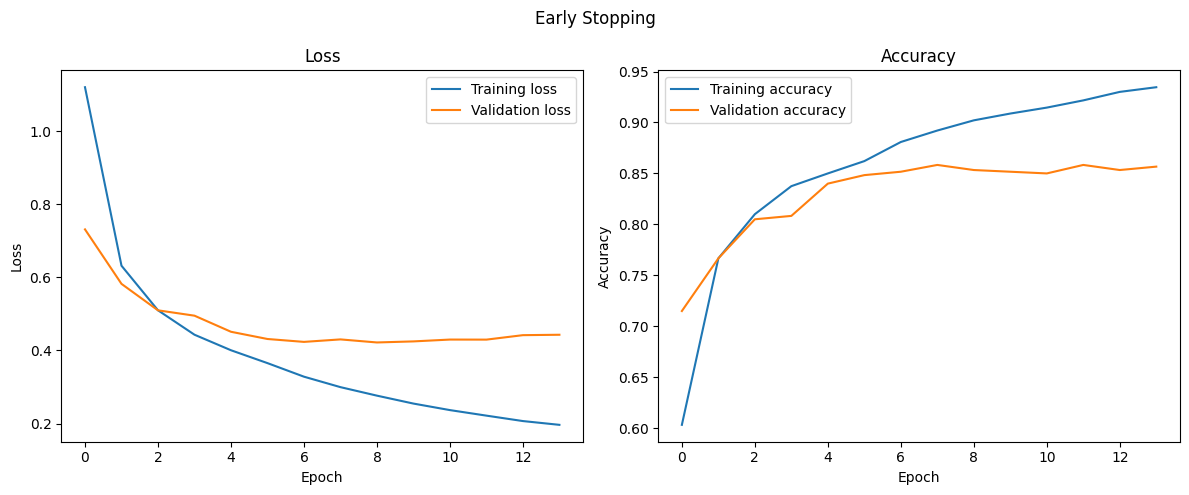

               name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
          Få epoker        0.853750    0.395047      0.838333  0.432139               5       3.690404
        Grundmodell        0.943333    0.182484      0.861667  0.457438              15       8.400747
       Många epoker        0.969583    0.077788      0.835000  0.681650              30      15.837261
        Liten batch        0.958333    0.126442      0.865000  0.487274              15      10.311773
       Normal batch        0.947917    0.153334      0.856667  0.493546              15       8.420186
         Stor batch        0.875417    0.358007      0.853333  0.454866              15       6.912342
          Få filter        0.926250    0.213105      0.855000  0.461891              15       5.884743
Grundmodell filters        0.921667    0.219979      0.838333  0.539367              15       8.749968
       Många filter        0.920000    0.213964      0.865000  0.480183  

In [14]:
# Experiment 4 – Regularisering

early_stop = EarlyStopping(patience=5, restore_best_weights=True)

h10, r10 = run_experiment("Ingen reg",      epochs=15, num_filters_1=16, num_filters_2=32, batch_size=32)
h11, r11 = run_experiment("Dropout 0.3",    epochs=15, dropout_rate=0.3, num_filters_1=16, num_filters_2=32, batch_size=32)
h12, r12 = run_experiment("Dropout 0.5",    epochs=15, dropout_rate=0.5, num_filters_1=16, num_filters_2=32, batch_size=32)
h13, r13 = run_experiment("L2",             epochs=15, l2_strength=0.001, num_filters_1=16, num_filters_2=32, batch_size=32)
h14, r14 = run_experiment("Early Stopping", epochs=15, callbacks=[early_stop], num_filters_1=16, num_filters_2=32, batch_size=32)
results_general.extend([r10, r11, r12, r13, r14])

print(pd.DataFrame(results_general).to_string(index=False))

In [15]:
best_model = build_model(num_filters_1=16, num_filters_2=32)


Optimizer: SGD
Antal epoker:       5
Train accuracy:      0.1417
Train loss:          2.2605
Validation accuracy: 0.1500
Validation loss:     2.2567
Träningstid:         2.95 sekunder


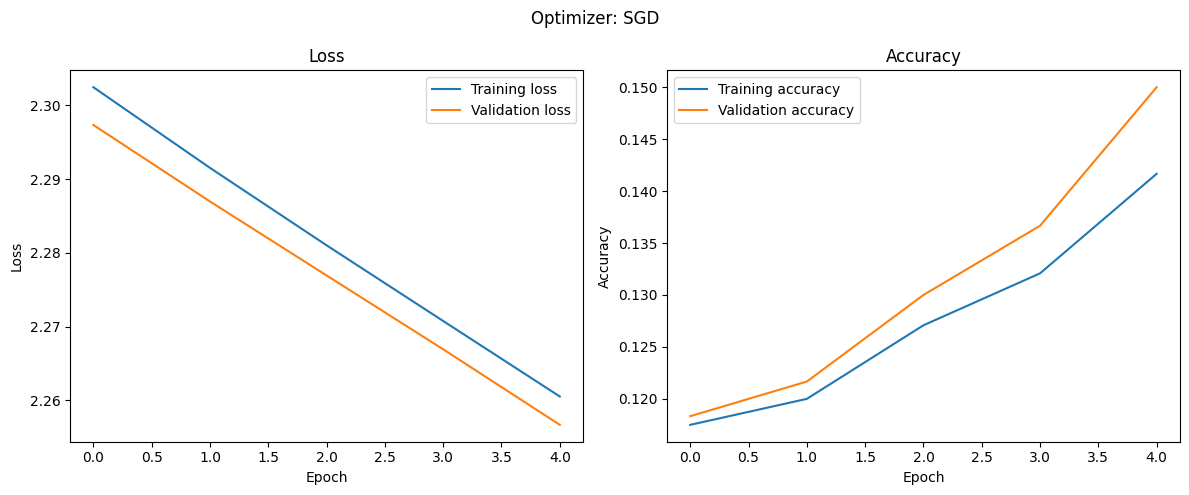


Optimizer: RMSprop
Antal epoker:       5
Train accuracy:      0.8525
Train loss:          0.3907
Validation accuracy: 0.8467
Validation loss:     0.4340
Träningstid:         3.27 sekunder


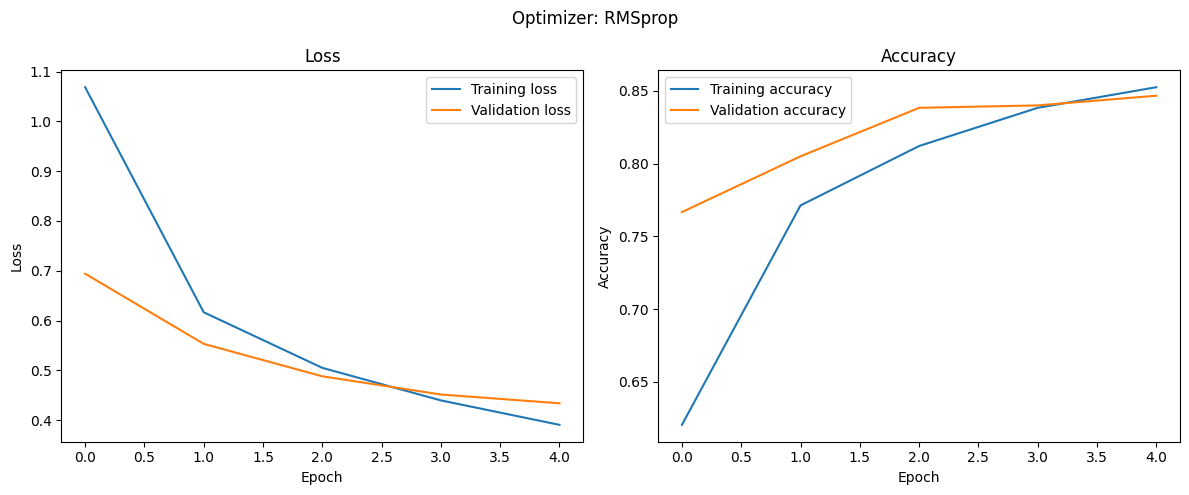


Optimizer: Adam
Antal epoker:       5
Train accuracy:      0.8783
Train loss:          0.3219
Validation accuracy: 0.8433
Validation loss:     0.4401
Träningstid:         3.52 sekunder


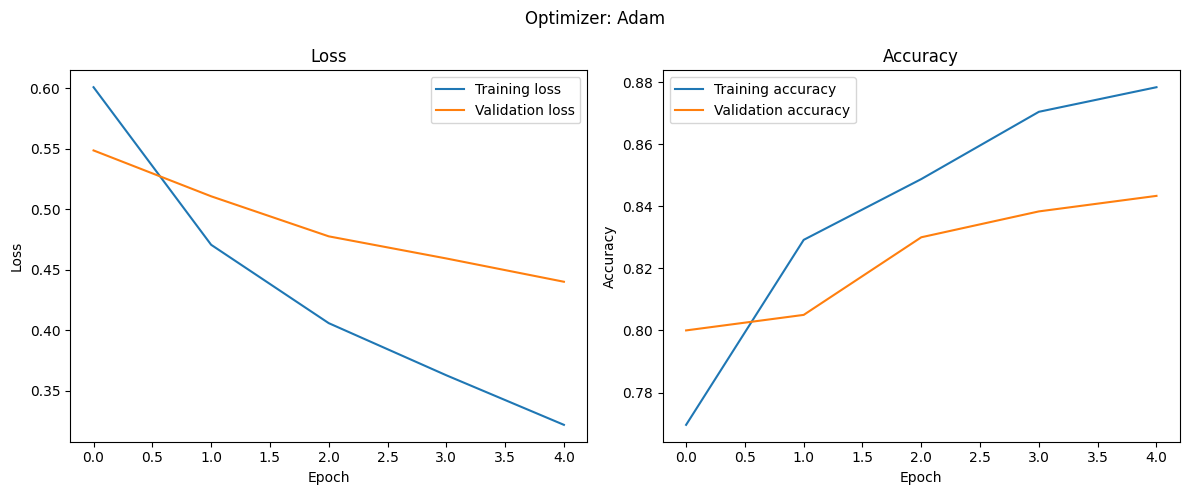

   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
    SGD        0.141667    2.260539      0.150000  2.256697               5       2.952929
RMSprop        0.852500    0.390678      0.846667  0.433959               5       3.269915
   Adam        0.878333    0.321893      0.843333  0.440070               5       3.516618


In [16]:
results_optimizers = []

optimizers = [
    ("SGD",     keras.optimizers.SGD(learning_rate=0.001)),
    ("RMSprop", keras.optimizers.RMSprop(learning_rate=0.001)),
    ("Adam",    keras.optimizers.Adam(learning_rate=0.001)),
]

for opt_name, opt in optimizers:
    best_model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nOptimizer: {opt_name}")
    start_time = time.time()

    history = best_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    training_time = time.time() - start_time

    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_acc   = history.history["val_accuracy"][-1]
    val_loss  = history.history["val_loss"][-1]

    print(f"Antal epoker:       {len(history.history['loss'])}")
    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    plot_history(history, title=f"Optimizer: {opt_name}")

    results_optimizers.append({
        "name":           opt_name,
        "train_accuracy": train_acc,
        "train_loss":     train_loss,
        "val_accuracy":   val_acc,
        "val_loss":       val_loss,
        "epochs_trained": len(history.history["loss"]),
        "training_time":  training_time
    })

print(pd.DataFrame(results_optimizers).to_string(index=False))


Konstant LR
Train accuracy:      0.9663
Validation accuracy: 0.8667
Train loss:          0.1170
Validation loss:     0.4847
Träningstid:         8.16 sekunder


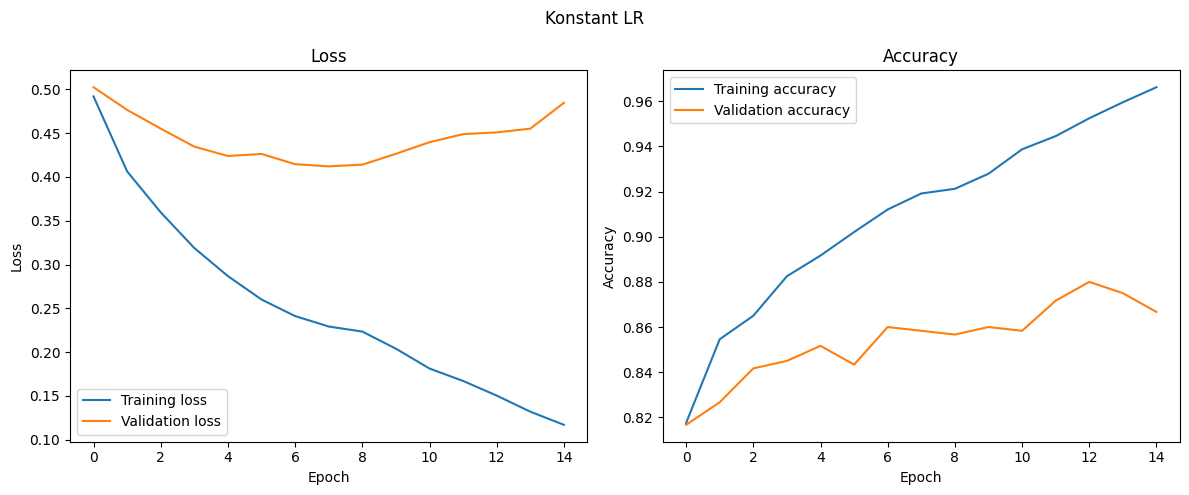


Låg LR
Train accuracy:      0.9929
Validation accuracy: 0.8683
Train loss:          0.0420
Validation loss:     0.4968
Träningstid:         8.05 sekunder


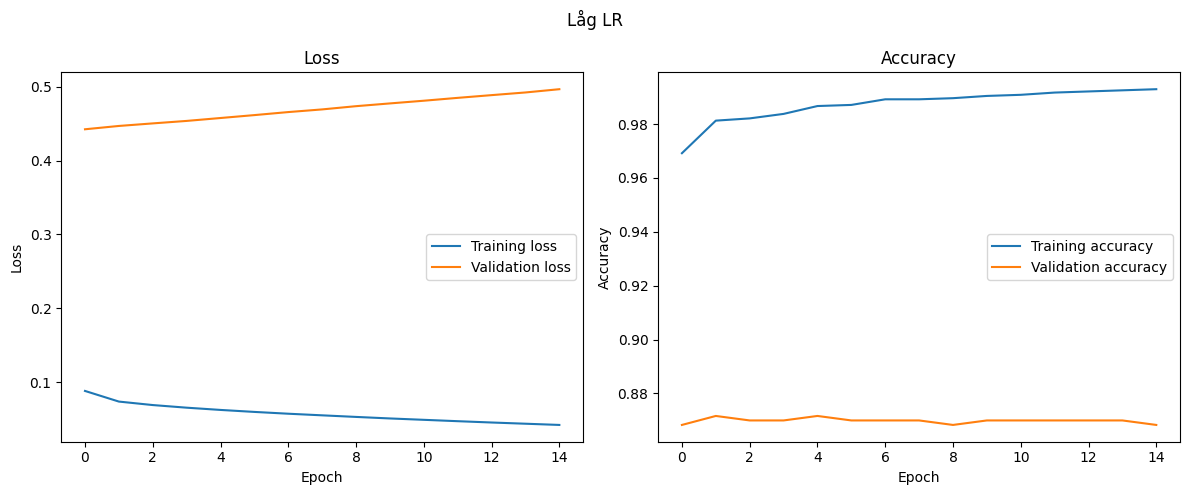


Hög LR
Train accuracy:      0.9525
Validation accuracy: 0.8133
Train loss:          0.1489
Validation loss:     1.0169
Träningstid:         7.99 sekunder


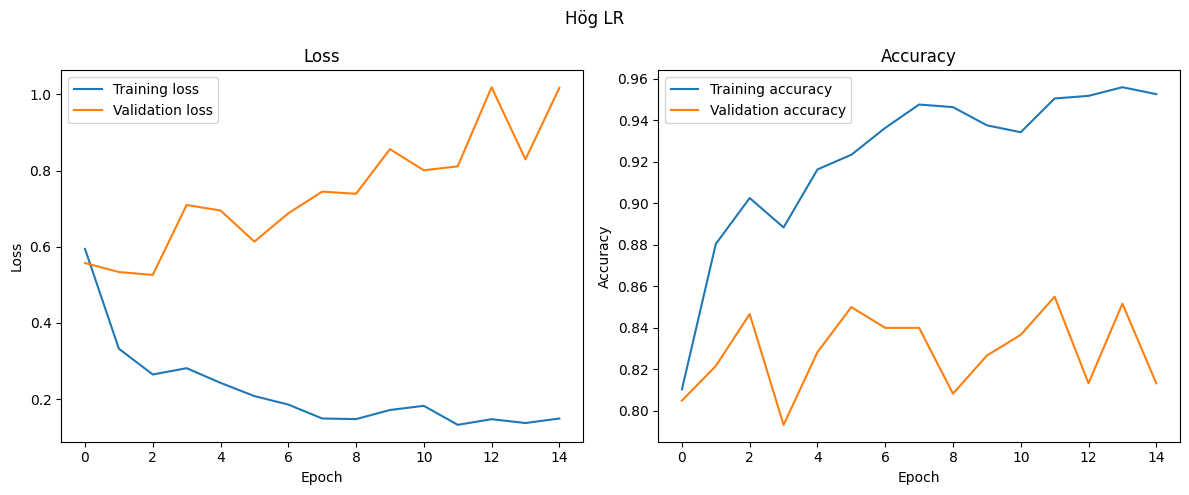


Step Decay
Train accuracy:      1.0000
Validation accuracy: 0.8550
Train loss:          0.0004
Validation loss:     1.2850
Träningstid:         7.87 sekunder


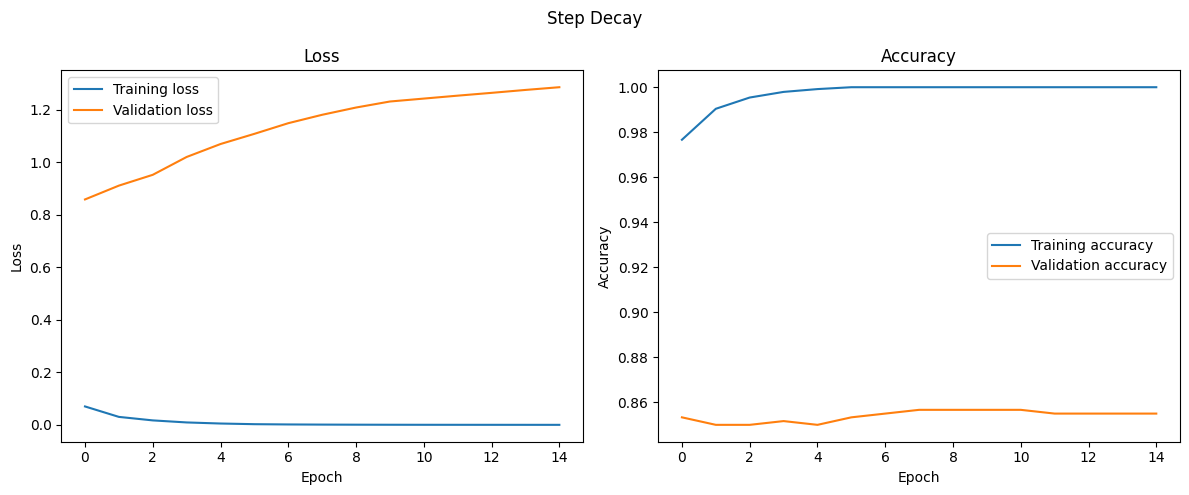


Cosine Annealing
Train accuracy:      1.0000
Validation accuracy: 0.8600
Train loss:          0.0000
Validation loss:     1.6016
Träningstid:         7.86 sekunder


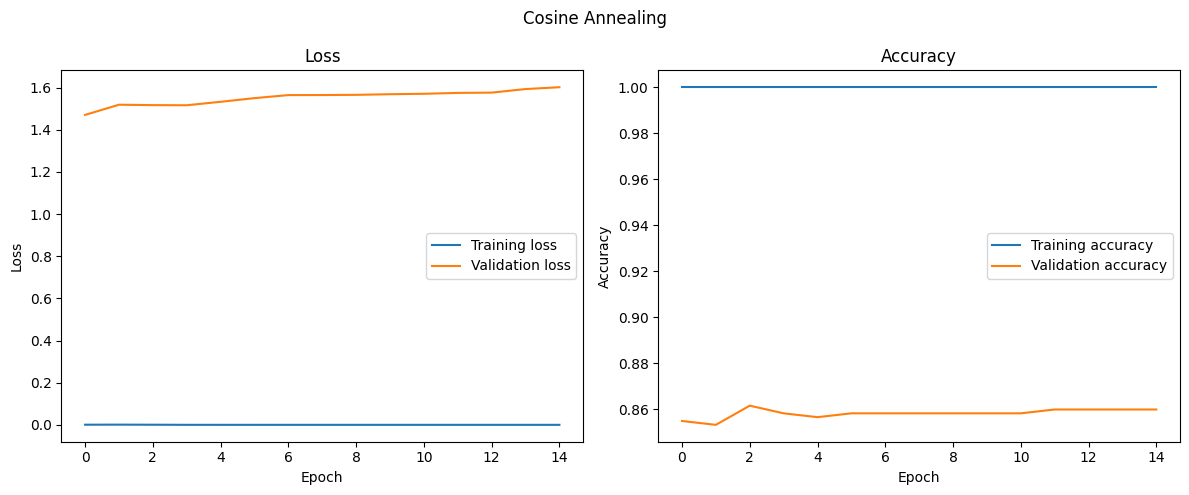


Reduce On Plateau
Train accuracy:      1.0000
Validation accuracy: 0.8483
Train loss:          0.0000
Validation loss:     1.9508
Träningstid:         7.82 sekunder


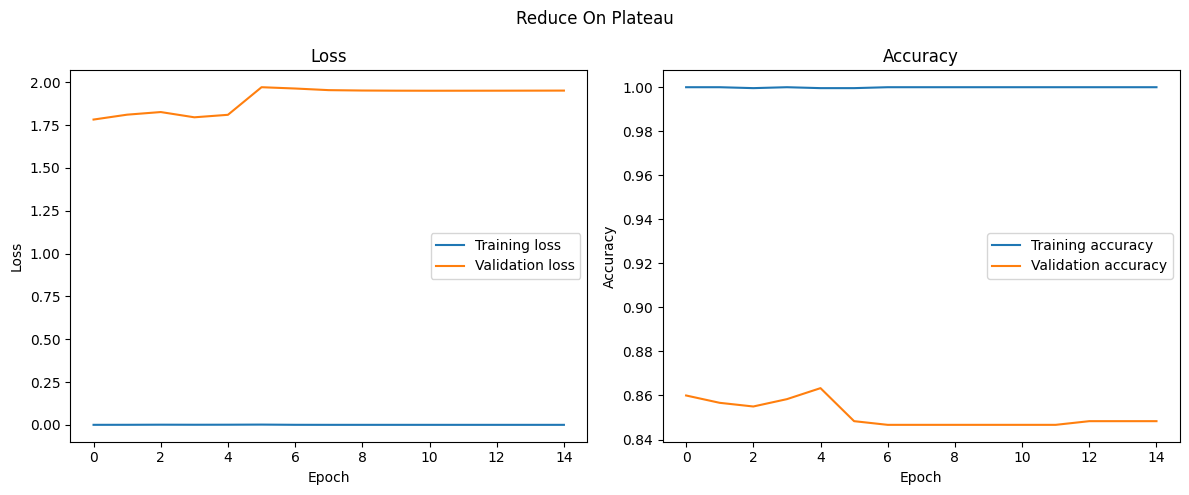

             name  train_accuracy  val_accuracy  train_loss  val_loss  training_time
      Konstant LR        0.966250      0.866667    0.117025  0.484706       8.159094
           Låg LR        0.992917      0.868333    0.042013  0.496821       8.050719
           Hög LR        0.952500      0.813333    0.148944  1.016945       7.986871
       Step Decay        1.000000      0.855000    0.000360  1.284971       7.869962
 Cosine Annealing        1.000000      0.860000    0.000019  1.601559       7.856990
Reduce On Plateau        1.000000      0.848333    0.000008  1.950847       7.815106


In [17]:
# Step Decay
def step_decay(epoch):
    return 0.001 * (0.5 ** (epoch // 10))
step_cb = LearningRateScheduler(step_decay)

# Cosine Annealing
def cosine_decay(epoch, total_epochs=30):
    return 0.001 * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
cos_cb = LearningRateScheduler(cosine_decay)

# Reduce On Plateau
plateau_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)

# Kör experimenten
results_lr = []

experiments = [
    ("Konstant LR",       0.001,  []),
    ("Låg LR",            0.0001, []),
    ("Hög LR",            0.01,   []),
    ("Step Decay",        0.001,  [step_cb]),
    ("Cosine Annealing",  0.001,  [cos_cb]),
    ("Reduce On Plateau", 0.001,  [plateau_cb]),
]

for exp_name, lr, callbacks in experiments:
    
    best_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    print(f"\n{exp_name}")
    start_time = time.time()

    history = best_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=15,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    training_time = time.time() - start_time

    val_acc    = history.history["val_accuracy"][-1]
    val_loss   = history.history["val_loss"][-1]
    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]

    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    plot_history(history, title=exp_name)

    results_lr.append({
        "name":           exp_name,
        "train_accuracy": train_acc,
        "val_accuracy":   val_acc,
        "train_loss":     train_loss,
        "val_loss":       val_loss,
        "training_time":  training_time
    })

print(pd.DataFrame(results_lr).to_string(index=False))

In [18]:
# Skapa valideringsset hela datasetet

X_train_full_raw, X_val_full_raw, y_train_full_split, y_val_full = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

In [19]:
# Normalisera hela datasetet

X_train_full_norm = X_train_full_raw.astype("float32") / 255.0
X_val_full_norm = X_val_full_raw.astype("float32") / 255.0

print("X_train_full_norm shape:", X_train_full_norm.shape)
print("X_val_full_norm shape:", X_val_full_norm.shape)

X_train_full_norm shape: (48000, 28, 28)
X_val_full_norm shape: (12000, 28, 28)



Optimizer: SGD
Antal epoker:       15
Train accuracy:      0.9452
Train loss:          0.1566
Validation accuracy: 0.9126
Validation loss:     0.2795
Träningstid:         109.17 sekunder


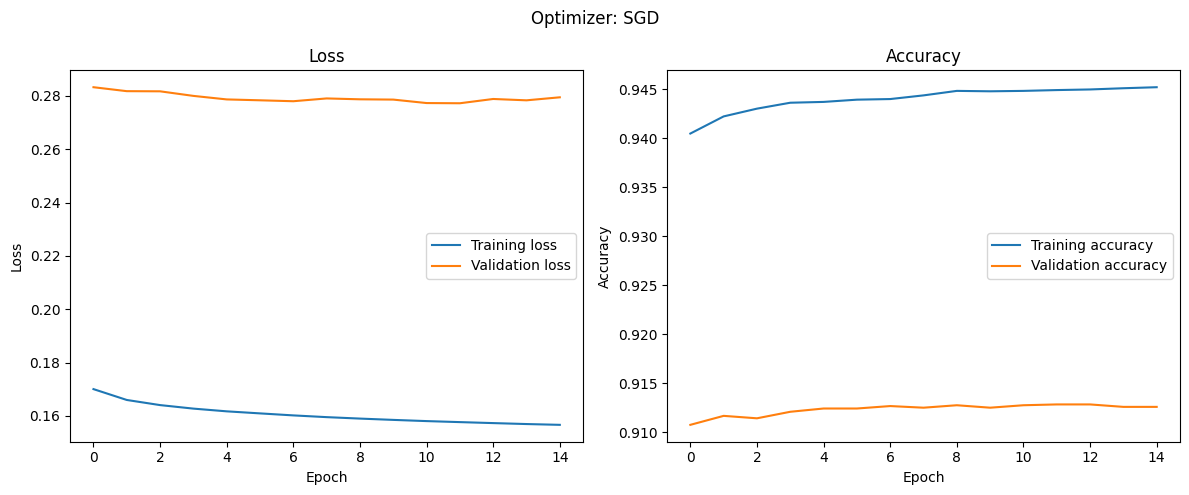


Optimizer: RMSprop
Antal epoker:       15
Train accuracy:      0.9728
Train loss:          0.0909
Validation accuracy: 0.8965
Validation loss:     0.6073
Träningstid:         108.78 sekunder


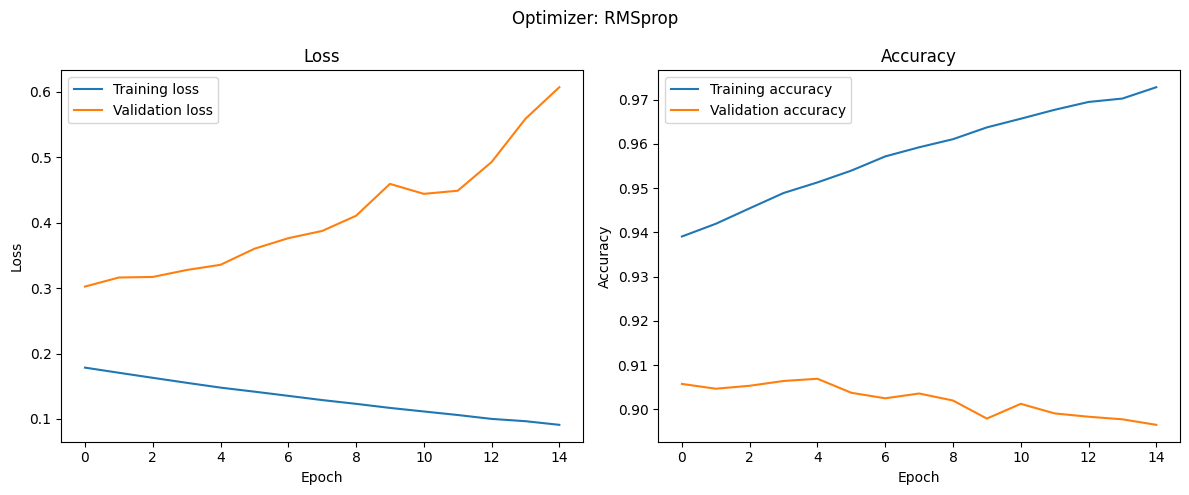


Optimizer: Adam
Antal epoker:       15
Train accuracy:      0.9927
Train loss:          0.0207
Validation accuracy: 0.9064
Validation loss:     0.7468
Träningstid:         112.96 sekunder


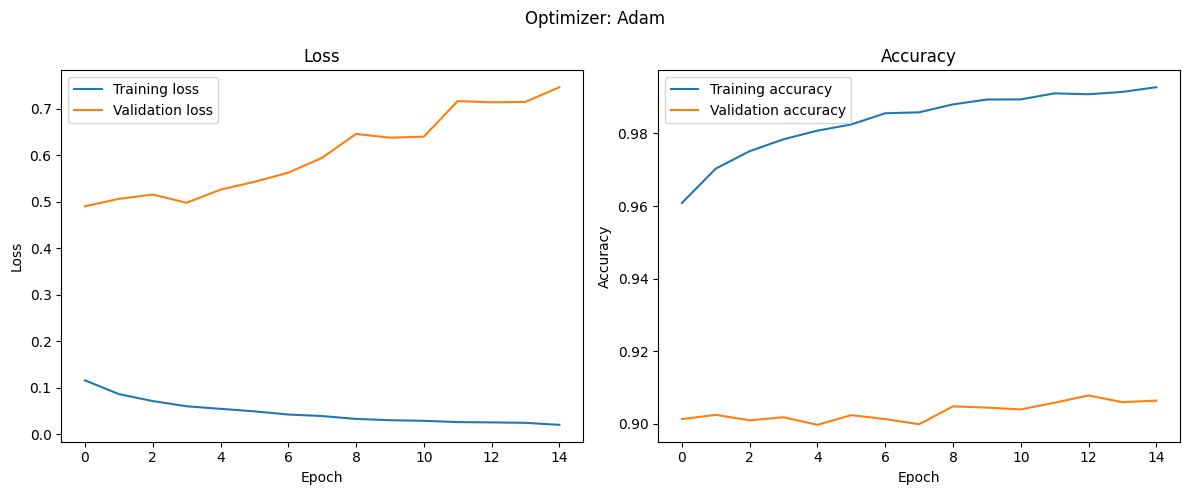

   name  train_accuracy  train_loss  val_accuracy  val_loss  epochs_trained  training_time
    SGD        0.945208    0.156631      0.912583  0.279505              15     109.169209
RMSprop        0.972833    0.090890      0.896500  0.607261              15     108.776481
   Adam        0.992708    0.020673      0.906417  0.746785              15     112.957691


In [21]:
# Optimizers på hela datasetet

results_optimizers = []

optimizers = [
    ("SGD",     keras.optimizers.SGD(learning_rate=0.001)),
    ("RMSprop", keras.optimizers.RMSprop(learning_rate=0.001)),
    ("Adam",    keras.optimizers.Adam(learning_rate=0.001)),
]

for opt_name, opt in optimizers:
    best_model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print(f"\nOptimizer: {opt_name}")
    start_time = time.time()

    history = best_model.fit(
        X_train_full_norm, y_train_full_split,
        validation_data=(X_val_full_norm, y_val_full),
        epochs=15,
        batch_size=32,
        verbose=0
    )

    training_time = time.time() - start_time

    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]
    val_acc   = history.history["val_accuracy"][-1]
    val_loss  = history.history["val_loss"][-1]

    print(f"Antal epoker:       {len(history.history['loss'])}")
    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    plot_history(history, title=f"Optimizer: {opt_name}")

    results_optimizers.append({
        "name":           opt_name,
        "train_accuracy": train_acc,
        "train_loss":     train_loss,
        "val_accuracy":   val_acc,
        "val_loss":       val_loss,
        "epochs_trained": len(history.history["loss"]),
        "training_time":  training_time
    })

print(pd.DataFrame(results_optimizers).to_string(index=False))

In [ ]:
# Learning rates på hela datasetet med Adam

# Step Decay
def step_decay(epoch):
    return 0.001 * (0.5 ** (epoch // 10))
step_cb = LearningRateScheduler(step_decay)

# Cosine Annealing
def cosine_decay(epoch, total_epochs=30):
    return 0.001 * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
cos_cb = LearningRateScheduler(cosine_decay)

# Reduce On Plateau
plateau_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)

# Kör experimenten
results_lr = []

experiments = [
    ("Konstant LR",       0.001,  [early_stop]),
    ("Låg LR",            0.0001, [early_stop]),
    ("Hög LR",            0.01,   [early_stop]),
    ("Step Decay",        0.001,  [step_cb, early_stop]),
    ("Cosine Annealing",  0.001,  [cos_cb, early_stop]),
    ("Reduce On Plateau", 0.001,  [plateau_cb, early_stop]),
]

for exp_name, lr, callbacks in experiments:
    
    best_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    print(f"\n{exp_name}")
    start_time = time.time()

    history = best_model.fit(
        X_train_full_norm, y_train_full_split,
        validation_data=(X_val_full_norm, y_val_full ),
        epochs=15,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    training_time = time.time() - start_time

    val_acc    = history.history["val_accuracy"][-1]
    val_loss   = history.history["val_loss"][-1]
    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]

    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    plot_history(history, title=exp_name)

    results_lr.append({
        "name":           exp_name,
        "train_accuracy": train_acc,
        "val_accuracy":   val_acc,
        "train_loss":     train_loss,
        "val_loss":       val_loss,
        "training_time":  training_time
    })

print(pd.DataFrame(results_lr).to_string(index=False))

In [ ]:
# Learning rates på hela datasetet med SGD

# Step Decay
def step_decay(epoch):
    return 0.001 * (0.5 ** (epoch // 10))
step_cb = LearningRateScheduler(step_decay)

# Cosine Annealing
def cosine_decay(epoch, total_epochs=30):
    return 0.001 * 0.5 * (1 + np.cos(np.pi * epoch / total_epochs))
cos_cb = LearningRateScheduler(cosine_decay)

# Reduce On Plateau
plateau_cb = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5)

# Kör experimenten
results_lr = []

experiments = [
    ("Konstant LR",       0.001,  [early_stop]),
    ("Låg LR",            0.0001, [early_stop]),
    ("Hög LR",            0.01,   [early_stop]),
    ("Step Decay",        0.001,  [step_cb, early_stop]),
    ("Cosine Annealing",  0.001,  [cos_cb, early_stop]),
    ("Reduce On Plateau", 0.001,  [plateau_cb, early_stop]),
]

for exp_name, lr, callbacks in experiments:
    
    best_model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    print(f"\n{exp_name}")
    start_time = time.time()

    history = best_model.fit(
        X_train_full_norm, y_train_full_split,
        validation_data=(X_val_full_norm, y_val_full ),
        epochs=15,
        batch_size=32,
        callbacks=callbacks,
        verbose=0
    )

    training_time = time.time() - start_time

    val_acc    = history.history["val_accuracy"][-1]
    val_loss   = history.history["val_loss"][-1]
    train_acc  = history.history["accuracy"][-1]
    train_loss = history.history["loss"][-1]

    print(f"Train accuracy:      {train_acc:.4f}")
    print(f"Validation accuracy: {val_acc:.4f}")
    print(f"Train loss:          {train_loss:.4f}")
    print(f"Validation loss:     {val_loss:.4f}")
    print(f"Träningstid:         {training_time:.2f} sekunder")

    plot_history(history, title=exp_name)

    results_lr.append({
        "name":           exp_name,
        "train_accuracy": train_acc,
        "val_accuracy":   val_acc,
        "train_loss":     train_loss,
        "val_loss":       val_loss,
        "training_time":  training_time
    })

print(pd.DataFrame(results_lr).to_string(index=False))